# Estimating regression fits

📄 Source: https://seaborn.pydata.org/tutorial/regression.html

Often the goal is to relate several quantitative variables. Seaborn can fit a simple model (linear regression) to two noisy variables and draw it.
Like Tukey's idea, these plots are **visual guides for exploration**. Seaborn is not a statistics package: for coefficients, p-values and fit statistics use **statsmodels**.

> Robust, logistic and lowess fits below need **statsmodels**: `pip install statsmodels`

In [1]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(color_codes=True)
np.random.seed(sum(map(ord, "regression")))   # docs' seed (bootstrapped bands)
print("seaborn", sns.__version__)

seaborn 0.13.2


## Functions for drawing linear regression models

`regplot` and `lmplot`. Both draw a scatterplot of `x` and `y`, fit **`y ~ x`**, and draw the regression line with a **95% confidence interval** band:

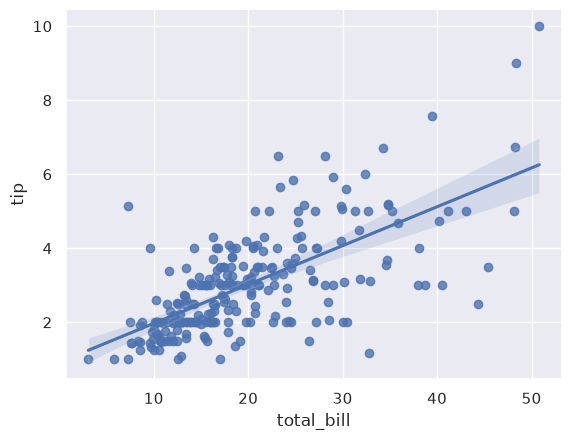

In [2]:
tips = sns.load_dataset("tips")
sns.regplot(x="total_bill", y="tip", data=tips);   # axes-level

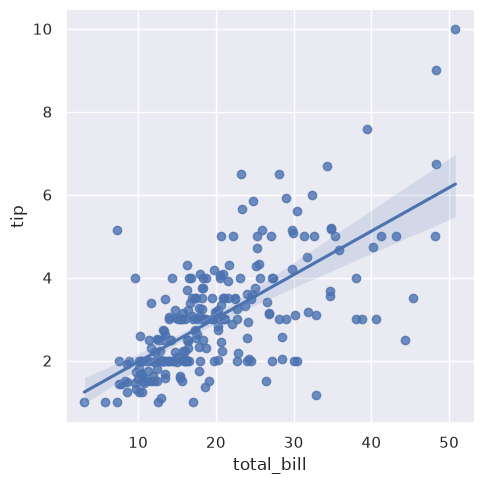

In [3]:
sns.lmplot(x="total_bill", y="tip", data=tips);    # figure-level

(The `;` at the end of a line hides the returned object's text in Jupyter.)

| | `regplot` | `lmplot` |
| :-- | :-- | :-- |
| level | **axes**-level (`ax=`) | **figure**-level (FacetGrid) |
| inputs | arrays, Series, or column names with `data=` | `data=` required, `x`/`y` as strings |
| `hue`, `col`, `row` | ✗ | ✓ |

The tutorial focuses on `lmplot`. With a **discrete** x variable the plain scatterplot isn't great:

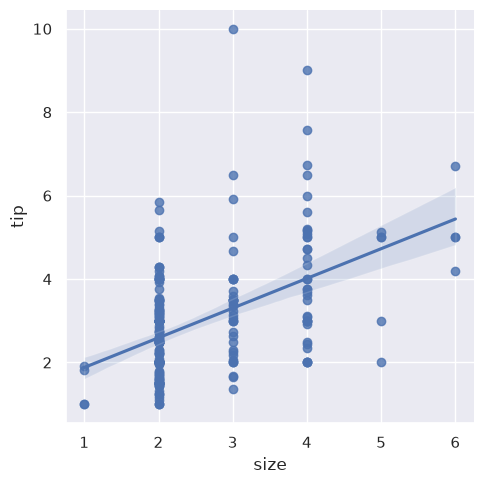

In [4]:
sns.lmplot(x="size", y="tip", data=tips);

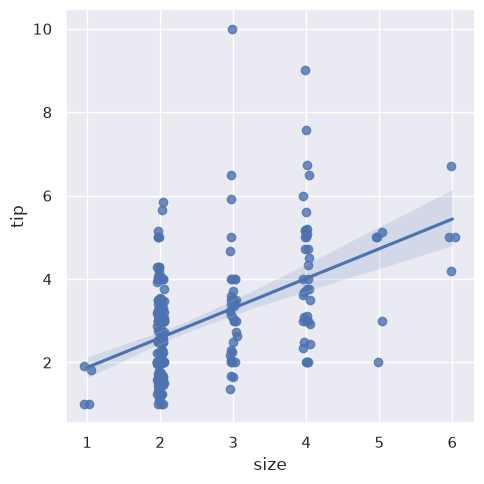

In [5]:
# Option 1: jitter the points (only the drawing, NOT the fit)
sns.lmplot(x="size", y="tip", data=tips, x_jitter=.05);

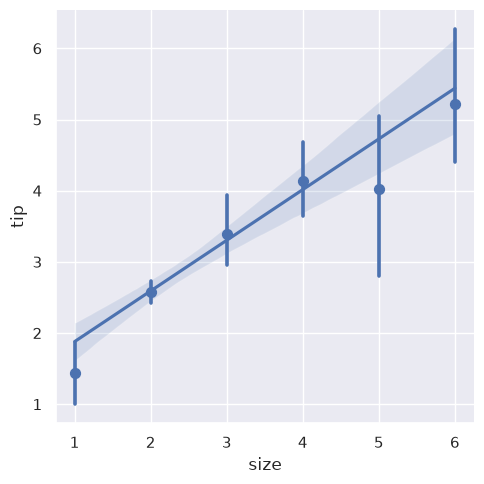

In [6]:
# Option 2: collapse each discrete x to an estimate (mean) + CI
sns.lmplot(x="size", y="tip", data=tips, x_estimator=np.mean);

## Fitting different kinds of models

Simple linear regression isn't right for every dataset. **Anscombe's quartet**: four datasets with the **same** regression line, but very different pictures.

Dataset I: linear regression is a good model.

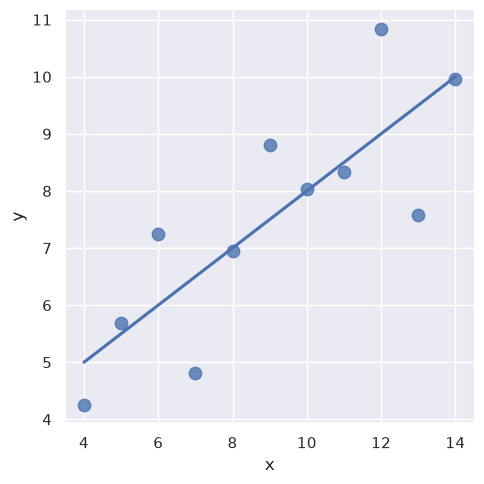

In [7]:
anscombe = sns.load_dataset("anscombe")
sns.lmplot(x="x", y="y", data=anscombe.query("dataset == 'I'"),
           ci=None, scatter_kws={"s": 80});   # scatter_kws -> passed to the scatter (bigger points)

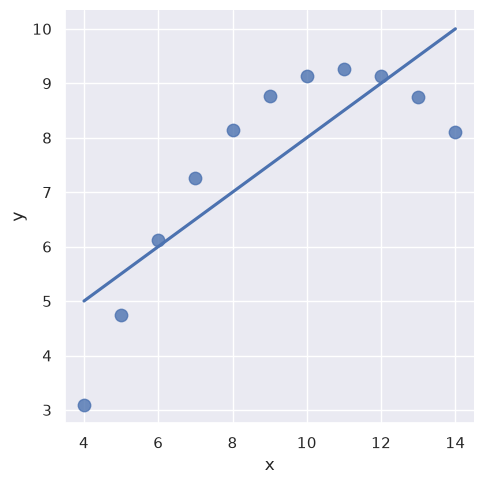

In [8]:
# Dataset II: same line, but the relationship is clearly curved
sns.lmplot(x="x", y="y", data=anscombe.query("dataset == 'II'"),
           ci=None, scatter_kws={"s": 80});

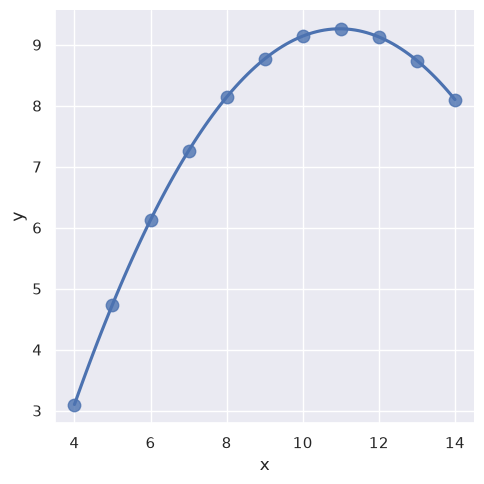

In [9]:
# Fit a polynomial regression: order=2 (quadratic)
sns.lmplot(x="x", y="y", data=anscombe.query("dataset == 'II'"),
           order=2, ci=None, scatter_kws={"s": 80});

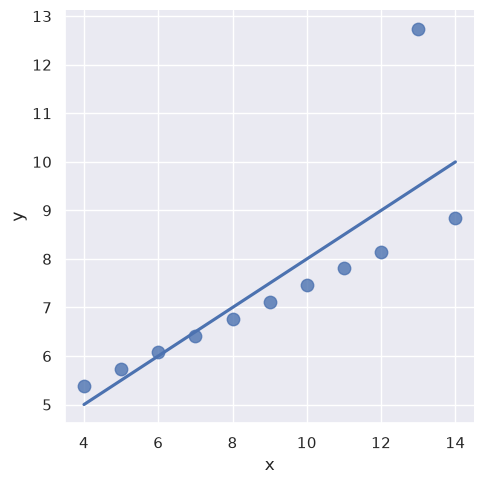

In [10]:
# Dataset III: one outlier pulls the line
sns.lmplot(x="x", y="y", data=anscombe.query("dataset == 'III'"),
           ci=None, scatter_kws={"s": 80});

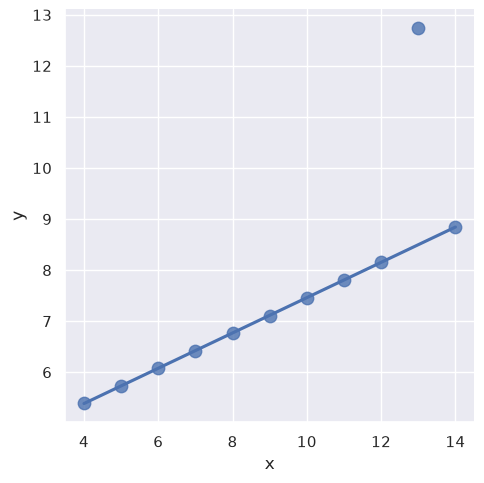

In [11]:
# Robust regression: a loss function that down-weights large residuals (needs statsmodels)
sns.lmplot(x="x", y="y", data=anscombe.query("dataset == 'III'"),
           robust=True, ci=None, scatter_kws={"s": 80});

**Binary y**: linear regression "works" but predicts impossible values (below 0, above 1):

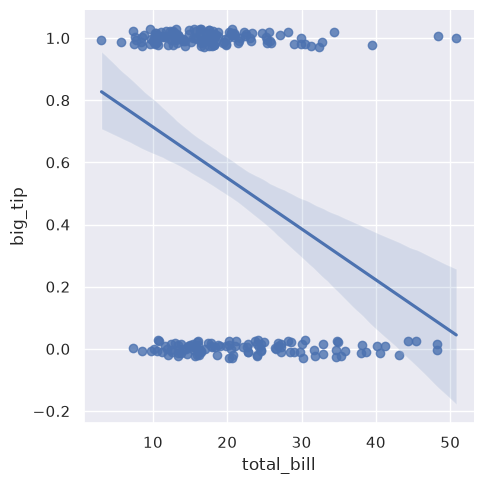

In [12]:
tips["big_tip"] = (tips.tip / tips.total_bill) > .15    # True/False: tip above 15%?
sns.lmplot(x="total_bill", y="big_tip", data=tips,
           y_jitter=.03);

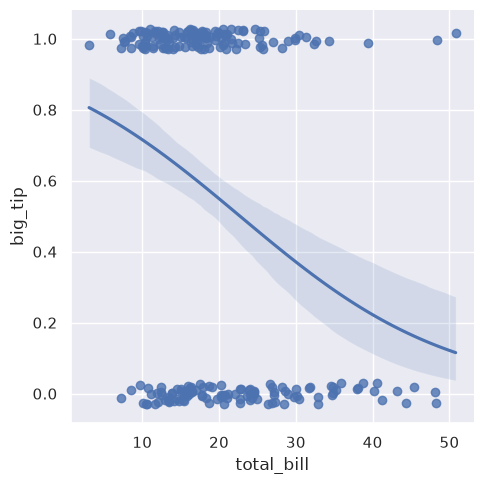

In [13]:
# Logistic regression: the line is the estimated P(y = 1) for each x (needs statsmodels)
sns.lmplot(x="total_bill", y="big_tip", data=tips,
           logistic=True, y_jitter=.03);

Logistic and robust fits are slower, and the CI band is bootstrapped; use `ci=None` to iterate faster.

**Lowess** (locally weighted) smoother: a non-parametric fit with the fewest assumptions. Expensive, so no CI is computed:

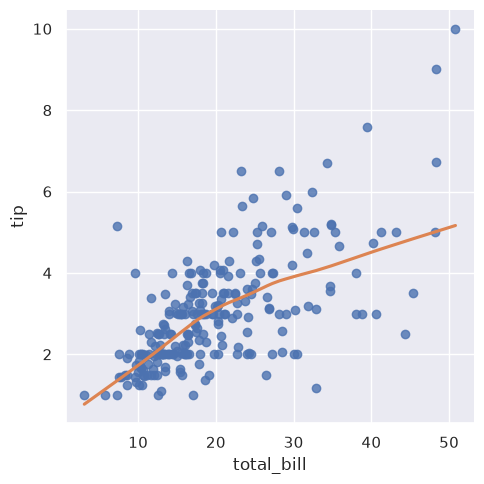

In [14]:
sns.lmplot(x="total_bill", y="tip", data=tips,
           lowess=True, line_kws={"color": "C1"});   # line_kws -> passed to the line

`residplot` checks whether simple linear regression is appropriate: it fits, removes the line, and plots the **residuals**. Ideally they're randomly scattered around y = 0:

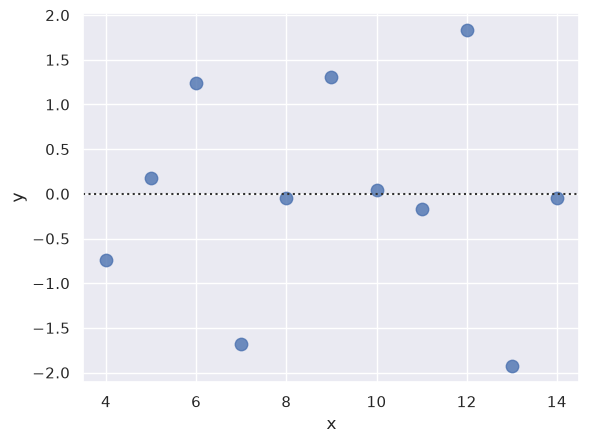

In [15]:
sns.residplot(x="x", y="y", data=anscombe.query("dataset == 'I'"),
              scatter_kws={"s": 80});   # random scatter: OK

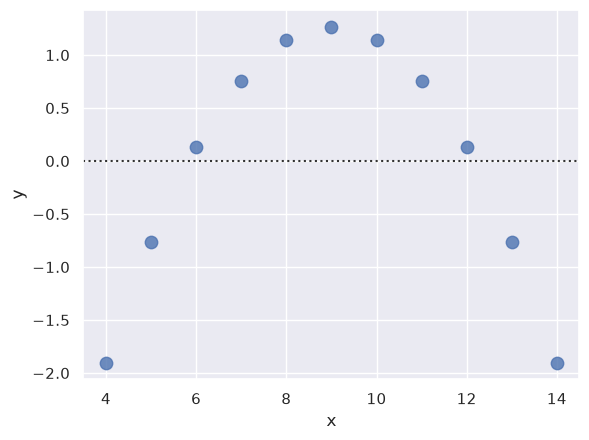

In [16]:
# Structure in the residuals (a curve) -> a straight line is the wrong model
sns.residplot(x="x", y="y", data=anscombe.query("dataset == 'II'"),
              scatter_kws={"s": 80});

## Conditioning on other variables

The more interesting question: **how does the x-y relationship change with a third variable?** Here `regplot` and `lmplot` differ: `regplot` always shows one relationship; `lmplot` = `regplot` + `FacetGrid`.

Best way to separate a relationship: both levels on the same axes, distinguished by colour:

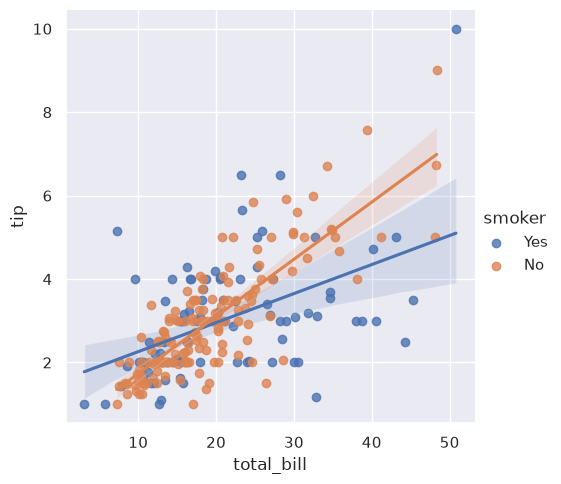

In [17]:
sns.lmplot(x="total_bill", y="tip", hue="smoker", data=tips);

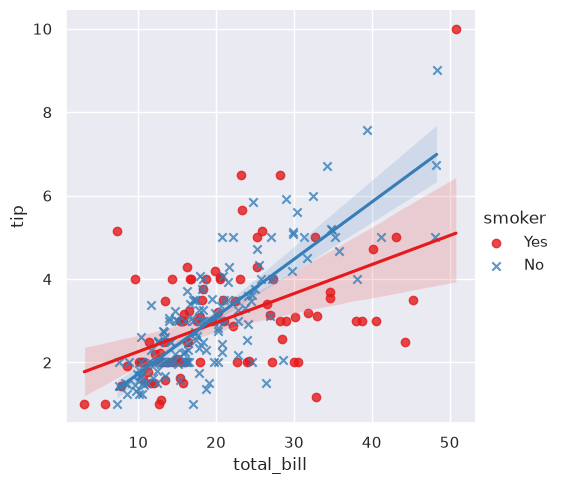

In [18]:
# No style semantic, but code hue redundantly with markers
sns.lmplot(x="total_bill", y="tip", hue="smoker", data=tips,
           markers=["o", "x"], palette="Set1");

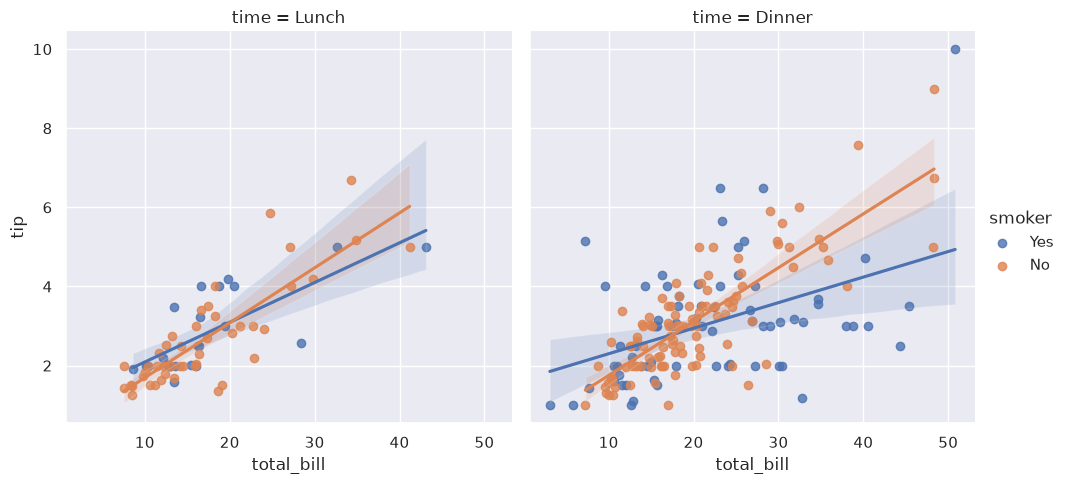

In [19]:
# Another variable -> facets
sns.lmplot(x="total_bill", y="tip", hue="smoker", col="time", data=tips);

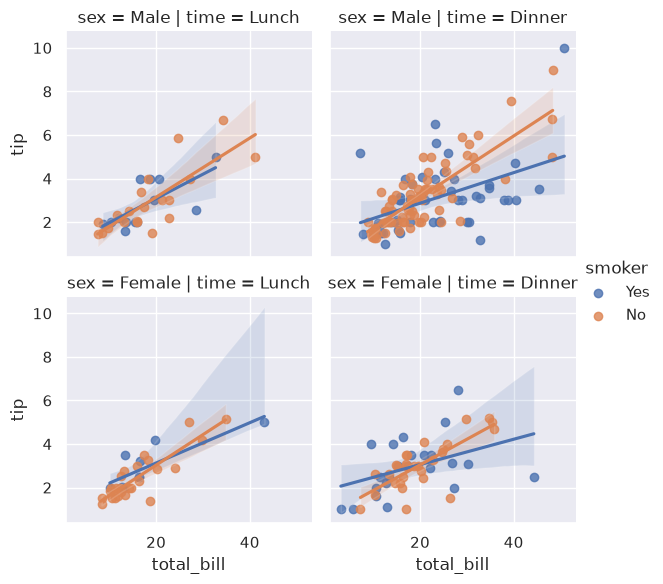

In [20]:
sns.lmplot(x="total_bill", y="tip", hue="smoker",
           col="time", row="sex", data=tips, height=3);

## Plotting a regression in other contexts

`jointplot(kind="reg")` puts a `regplot` in the joint axes:

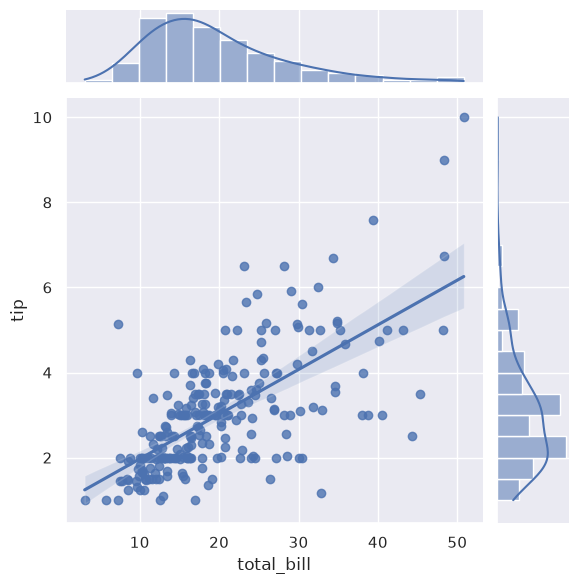

In [21]:
sns.jointplot(x="total_bill", y="tip", data=tips, kind="reg");

`pairplot(kind="reg")` = `regplot` + `PairGrid`. Careful: unlike `lmplot`, the panels show **different pairs of variables**, not the same relationship split by a third variable:

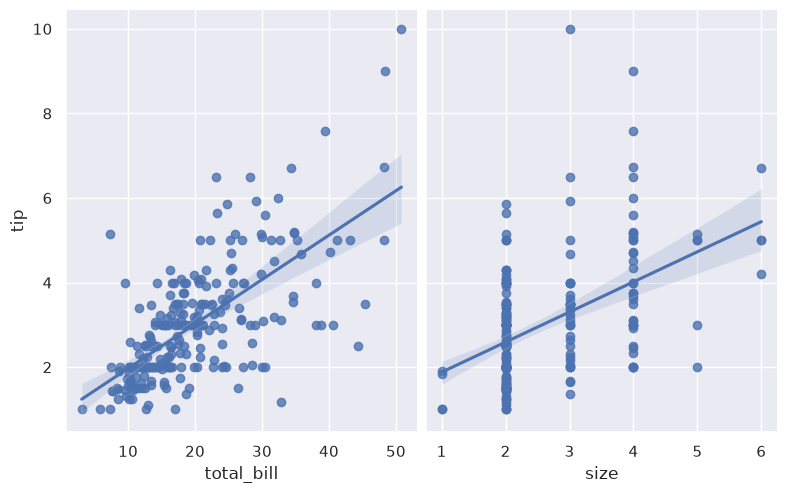

In [22]:
sns.pairplot(tips, x_vars=["total_bill", "size"], y_vars=["tip"],
             height=5, aspect=.8, kind="reg");

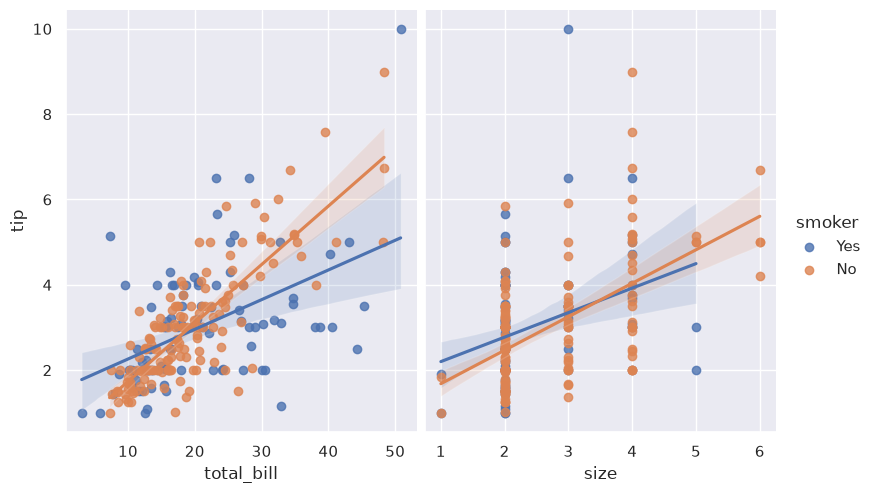

In [23]:
# hue works in both
sns.pairplot(tips, x_vars=["total_bill", "size"], y_vars=["tip"],
             hue="smoker", height=5, aspect=.8, kind="reg");

## Roadmap chart #3 (my addition): scatter + trend line inside my own `fig, ax`

`regplot` is axes-level, so it fits into a matplotlib layout and can be finished with matplotlib calls:

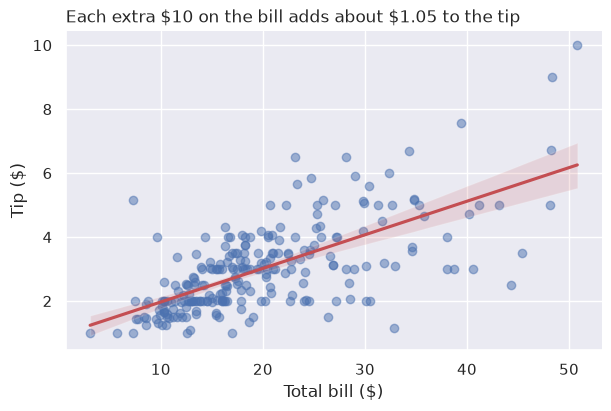

In [24]:
fig, ax = plt.subplots(figsize=(6, 4), layout="constrained")
sns.regplot(data=tips, x="total_bill", y="tip", ax=ax,
            scatter_kws={"alpha": .5}, line_kws={"color": "C3"})

slope, intercept = np.polyfit(tips["total_bill"], tips["tip"], 1)   # same straight-line fit, as numbers
ax.set_title(f"Each extra \\$10 on the bill adds about \\${slope * 10:.2f} to the tip", loc="left")   # \\$ = a literal $ (two $ would start math text)
ax.set(xlabel="Total bill ($)", ylabel="Tip ($)")
ax.spines[["top", "right"]].set_visible(False)

## Key takeaways

- `regplot` (axes-level, `ax=`) vs `lmplot` (figure-level, `hue`/`col`/`row`).
- Discrete x: `x_jitter=` or `x_estimator=np.mean`. Binary y: `logistic=True`.
- Curves: `order=2`; outliers: `robust=True`; no assumptions: `lowess=True`.
- Check the model with `residplot`: residuals should look random around 0.
- The band is a bootstrapped 95% CI (`ci=None` to turn it off). For real statistics, use statsmodels.